In [1]:
import torch
import torch.distributions as dist
import torch.nn as nn
import matplotlib.pyplot as plt


from typing import Tuple
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam


In [2]:
## net predicts noise and uses score matching noise loss
## one dimension of noise for each dimension in the data
class Net(nn.Module):

    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()

        ## input dim is dims of points + 1 for time idx
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x, t):
        t_expanded = t.expand(x.size(0),  x.size(1), 1)
        x = torch.cat([x, t_expanded], dim = -1)
        return self.net(x)
    
def add_noise(x, t, noise):
    x = t * x + (1 - t) * noise
    return x

In [3]:


class DiffusionDataset(Dataset):
    def __init__(self, target_samples: torch.Tensor):
        self.target_samples = target_samples
        
    def __len__(self):
        return self.target_samples.size(0)
    
    def __getitem__(self, idx):
        target_sample = self.target_samples[idx, ...]
        return target_sample

def generate_circle_sample(dims: tuple) -> torch.Tensor:
    p_target = dist.Uniform(low = torch.zeros((1,)), high = 2.0*torch.pi)
    target_samples = p_target.sample(dims)
    x = torch.cos(target_samples)
    y = torch.sin(target_samples)
    return torch.cat([x, y], dim=-1)



In [8]:
num_samples, points_per_sample = 256*4, 100

target_samples = generate_circle_sample(dims = (num_samples, points_per_sample))

training_data = DiffusionDataset(
    target_samples=target_samples,
)

train_dataloader = DataLoader(
    training_data, 
    batch_size = 256
)

Iter 1: Loss=0.9609584212303162...
Iter 101: Loss=0.3320041596889496...
Iter 201: Loss=0.30610549449920654...
Iter 301: Loss=0.30493733286857605...
Iter 401: Loss=0.2964978516101837...


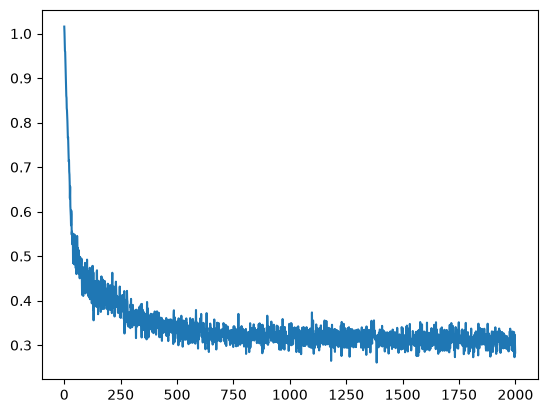

In [9]:
criterion = nn.MSELoss()
model = Net(input_dim = 2, output_dim = 2)
optimizer = Adam(params = model.parameters(), lr = 0.001)

num_epochs = 500
losses = []
for i, epoch in enumerate(range(num_epochs)):
    model.train()

    for target_sample in train_dataloader:
        optimizer.zero_grad()
        t = torch.rand(target_sample.size(0), 1, 1)
        noise = torch.randn_like(target_sample)
        noised_target_sample = add_noise(target_sample, t, noise)
        outputs = model(noised_target_sample, t)

        loss = criterion(outputs, noise)
        loss.backward()
        losses.append(loss.detach().numpy())
        optimizer.step()
    if i % 100 == 0:
        print(f"Iter {i + 1}: Loss={loss}...")

        

plt.plot(losses)

figure out how to sample from the diffusion model

In [10]:
@torch.no_grad()
def euler_maruyama(
        X0: torch.Tensor, 
        model: nn.Module, 
        num_steps: int, 
    ) -> torch.Tensor:
    t = torch.tensor([0.05]).expand(X0.size(0), X0.size(1), 1)
    h = torch.tensor([1/num_steps])
    Xt = X0.clone()
    for _ in range(num_steps):
        Xt = Xt + h * (Xt - model(Xt, t)) / t
        t = t + h
    return Xt

p_init = dist.MultivariateNormal(loc = torch.zeros((2,)), covariance_matrix = torch.eye(2))
initial_samples = p_init.sample((num_samples, points_per_sample))
X0 = initial_samples[40][None, :, :]

Xt = euler_maruyama(X0=X0, model=model, num_steps = 500)

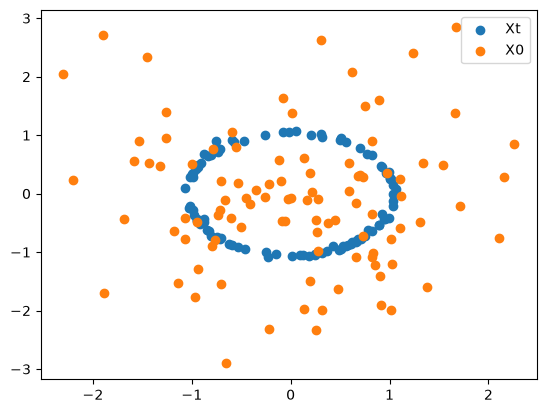

In [11]:
to_plot = Xt.squeeze(0).detach().numpy()
plt.scatter(
    x = to_plot[ :, 0],
    y = to_plot[ :, 1],
    label = 'Xt'
)

initial_to_plot = X0.squeeze(0).detach().numpy()
plt.scatter(
    x = initial_to_plot[ :, 0],
    y = initial_to_plot[ :, 1],
    label = 'X0'
)
plt.legend()
plt.show()